Categorización de Variables Numéricas de base de datos GAC

In [1]:
#Importamos las librerias pandas, numpy, matplotlib y display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
CARPETA = '/Users/jos/Downloads/Base_Datos_GAC/Actividad 4.2'

In [3]:
#Cargamos los archivos que contienen las variables numericas
Citas        = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(Citas Digital).csv', low_memory=False)
SDC          = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(SDC ).csv', header=None)
CPL_FB       = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(CPL FACEBOOK).csv', header=None)
VentasAsesor = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(Ventas por Asesor ).csv', header=None)
Conversac    = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(Conversaciones por Asesor).csv', header=None)
TopsMKT      = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(TOPS MKT).csv', header=None)
TopsVentas   = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(TOPS VENTAS).csv', header=None)
Piso         = pd.read_csv(f'{CARPETA}/Analisis GAC Full7agosto 2026(Analisis de Piso ).csv', header=None)

In [ ]:
#Extraemos cada variable numerica como una sola columna de datos
Potencial_compra = Citas['Potencial de compra'].str.replace('%', '', regex=False)
Potencial_compra = pd.to_numeric(Potencial_compra, errors='coerce')

SDC_Generadas  = pd.to_numeric(SDC.iloc[5, 1:32], errors='coerce')
SDC_Aprobadas  = pd.to_numeric(SDC.iloc[6, 1:32], errors='coerce')

Leads_Facebook = pd.to_numeric(CPL_FB.iloc[2, 1:14], errors='coerce')
Costo_por_Lead = CPL_FB.iloc[4, 1:14].str.replace('$', '', regex=False).str.strip()
Costo_por_Lead = pd.to_numeric(Costo_por_Lead, errors='coerce')

Ventas_x_Mes   = pd.to_numeric(VentasAsesor.iloc[2, 1:31], errors='coerce')
Conversaciones = pd.to_numeric(Conversac.iloc[1:, 1], errors='coerce')
Real_Pisos     = pd.to_numeric(TopsMKT.iloc[3, 1:12], errors='coerce')
Objetivo_Ventas= pd.to_numeric(TopsVentas.iloc[2, 1:13], errors='coerce')
Leads_x_Asesor = pd.to_numeric(Piso.iloc[4:, 16], errors='coerce')

In [ ]:
#Corroboramos valores nulos de la variable 
Potencial_compra.isnull().sum()

np.int64(1047964)

In [6]:
#Quitamos nulos y calculamos el numero total de la poblacion 'n'
Potencial_compra = Potencial_compra.dropna()
n = len(Potencial_compra)
n

611

In [7]:
#Obtenemos el limite superior y el limite inferior de la variable
Max = Potencial_compra.max()
Min = Potencial_compra.min()
Limites = [Min, Max]
Limites

[np.float64(5.0), np.float64(100.0)]

In [8]:
#Calculamos el rango R
R = Max - Min
R

np.float64(95.0)

In [9]:
#Calculamos el numero de Intervalos de Clase 'ni', aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni

np.float64(10.24965681800528)

In [10]:
#Redondeamos ni al entero mas cercano para obtener el numero de clases
num_clases = round(ni)
num_clases

10

In [11]:
#Calculamos el Ancho del Intervalo 'i'
i = R/num_clases
i

np.float64(9.5)

In [12]:
#Creamos los limites de cada intervalo
intervalos = np.linspace(Min, Max, num_clases+1)
intervalos

array([  5. ,  14.5,  24. ,  33.5,  43. ,  52.5,  62. ,  71.5,  81. ,
        90.5, 100. ])

In [13]:
#Creamos las etiquetas de cada categoria a partir de los intervalos
categorias = [f'Cat{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(num_clases)]
categorias

['Cat1 (5.0 - 14.5)',
 'Cat2 (14.5 - 24.0)',
 'Cat3 (24.0 - 33.5)',
 'Cat4 (33.5 - 43.0)',
 'Cat5 (43.0 - 52.5)',
 'Cat6 (52.5 - 62.0)',
 'Cat7 (62.0 - 71.5)',
 'Cat8 (71.5 - 81.0)',
 'Cat9 (81.0 - 90.5)',
 'Cat10 (90.5 - 100.0)']

In [14]:
#Finalmente creamos las categorias a partir de la variable numerica
Potencial_compra_cat = pd.cut(Potencial_compra, bins=intervalos, labels=categorias, include_lowest=True)
Potencial_compra_cat

0      Cat9 (81.0 - 90.5)
1      Cat4 (33.5 - 43.0)
2      Cat9 (81.0 - 90.5)
3      Cat9 (81.0 - 90.5)
4      Cat9 (81.0 - 90.5)
              ...        
684    Cat5 (43.0 - 52.5)
685    Cat8 (71.5 - 81.0)
687    Cat8 (71.5 - 81.0)
688    Cat9 (81.0 - 90.5)
689    Cat5 (43.0 - 52.5)
Name: Potencial de compra, Length: 611, dtype: category
Categories (10, str): ['Cat1 (5.0 - 14.5)' < 'Cat2 (14.5 - 24.0)' < 'Cat3 (24.0 - 33.5)' < 'Cat4 (33.5 - 43.0)' ... 'Cat7 (62.0 - 71.5)' < 'Cat8 (71.5 - 81.0)' < 'Cat9 (81.0 - 90.5)' < 'Cat10 (90.5 - 100.0)']

In [15]:
#Obtenemos un analisis univariado de la variable ya categorizada
Tabla_freq = Potencial_compra_cat.value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Categoria', 'count']
Tabla_freq

,Categoria,count
0,Cat1 (5.0 - 14.5),1
1,Cat2 (14.5 - 24.0),2
2,Cat3 (24.0 - 33.5),4
3,Cat4 (33.5 - 43.0),2
4,Cat5 (43.0 - 52.5),47
5,Cat6 (52.5 - 62.0),70
6,Cat7 (62.0 - 71.5),174
7,Cat8 (71.5 - 81.0),237
8,Cat9 (81.0 - 90.5),55
9,Cat10 (90.5 - 100.0),19


In [16]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Categoria')
Filtro_index

,count
Categoria,
Cat1 (5.0 - 14.5),1
Cat2 (14.5 - 24.0),2
Cat3 (24.0 - 33.5),4
Cat4 (33.5 - 43.0),2
Cat5 (43.0 - 52.5),47
Cat6 (52.5 - 62.0),70
Cat7 (62.0 - 71.5),174
Cat8 (71.5 - 81.0),237
Cat9 (81.0 - 90.5),55


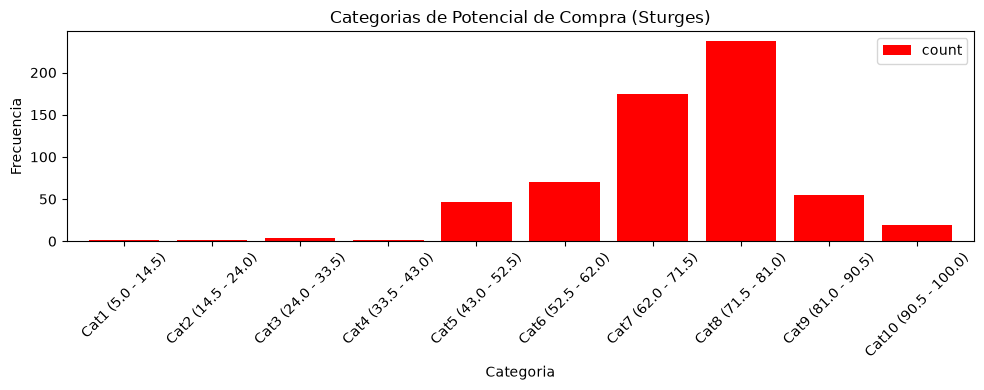

In [17]:
#Realizamos grafico de barras de las categorias obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red', rot=45)
plt.title('Categorias de Potencial de Compra (Sturges)')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [18]:
#Funcion que aplica la regla de Sturges y grafica las categorias resultantes
def categorizar_sturges(datos, nombre):
    datos = datos.dropna()
    n = len(datos)
    Min, Max = datos.min(), datos.max()
    R = Max - Min
    ni = 1 + 3.32*np.log10(n)          # regla de Sturges
    num_clases = round(ni)
    intervalos = np.linspace(Min, Max, num_clases+1)
    categorias = [f'Cat{k+1} ({intervalos[k]:.1f}-{intervalos[k+1]:.1f})' for k in range(num_clases)]

    datos_cat = pd.cut(datos, bins=intervalos, labels=categorias, include_lowest=True)
    tabla = datos_cat.value_counts().sort_index().reset_index()
    tabla.columns = ['Categoria', 'count']
    print(f'--- {nombre} (n={n}, {num_clases} clases) ---')
    display(tabla)

    tabla.set_index('Categoria').plot(kind='bar', figsize=(9,3.5), color='red', rot=45)
    plt.title(nombre)
    plt.xlabel('Categoria (Sturges)')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
    return tabla

--- Solicitudes de credito generadas (SDC) (n=31, 6 clases) ---


,Categoria,count
0,Cat1 (5.0-26.8),5
1,Cat2 (26.8-48.7),3
2,Cat3 (48.7-70.5),3
3,Cat4 (70.5-92.3),10
4,Cat5 (92.3-114.2),7
5,Cat6 (114.2-136.0),3


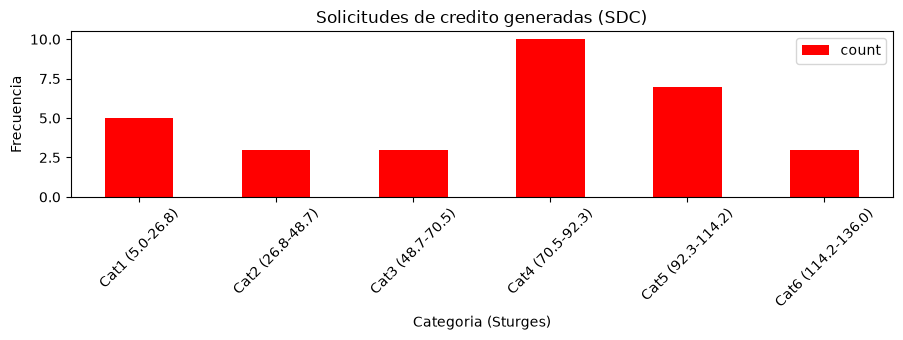

--- Solicitudes de credito aprobadas (SDC) (n=31, 6 clases) ---


,Categoria,count
0,Cat1 (1.0-9.3),4
1,Cat2 (9.3-17.7),3
2,Cat3 (17.7-26.0),3
3,Cat4 (26.0-34.3),7
4,Cat5 (34.3-42.7),9
5,Cat6 (42.7-51.0),5


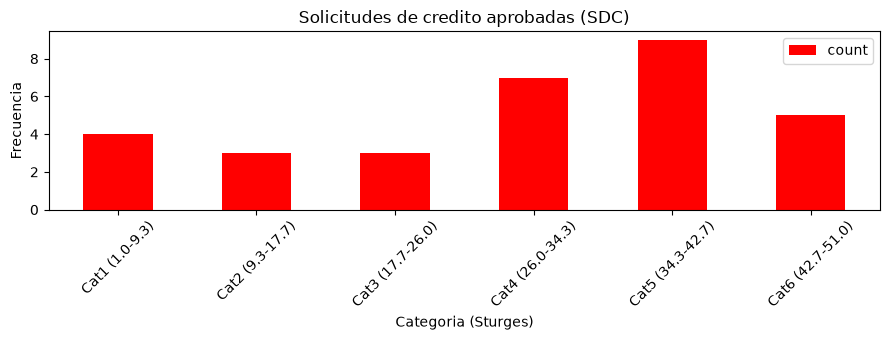

--- Leads Facebook por mes (CPL Facebook) (n=13, 5 clases) ---


,Categoria,count
0,Cat1 (211.0-253.2),3
1,Cat2 (253.2-295.4),5
2,Cat3 (295.4-337.6),1
3,Cat4 (337.6-379.8),2
4,Cat5 (379.8-422.0),2


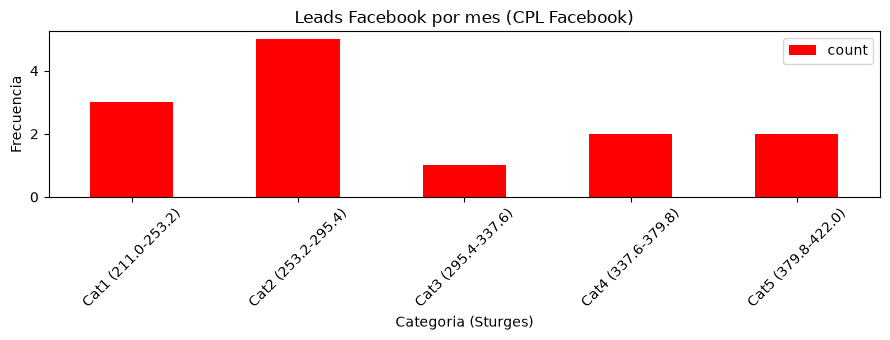

--- Costo por lead Facebook (CPL Facebook) (n=13, 5 clases) ---


,Categoria,count
0,Cat1 (116.2-162.8),3
1,Cat2 (162.8-209.5),3
2,Cat3 (209.5-256.1),0
3,Cat4 (256.1-302.8),3
4,Cat5 (302.8-349.5),4


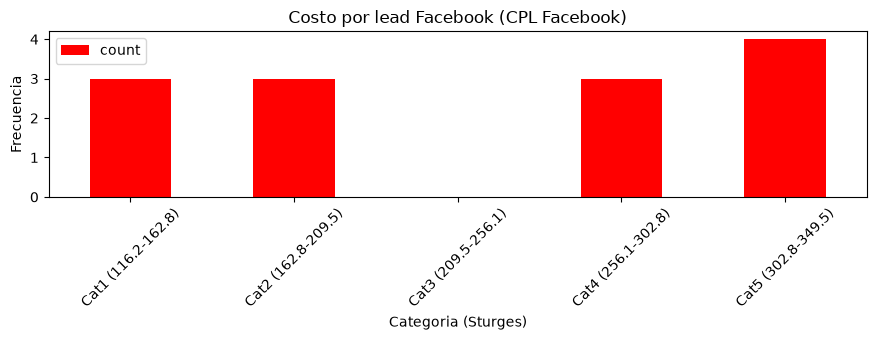

--- Ventas por mes (Ventas por Asesor) (n=30, 6 clases) ---


,Categoria,count
0,Cat1 (6.0-12.0),5
1,Cat2 (12.0-18.0),3
2,Cat3 (18.0-24.0),4
3,Cat4 (24.0-30.0),4
4,Cat5 (30.0-36.0),6
5,Cat6 (36.0-42.0),8


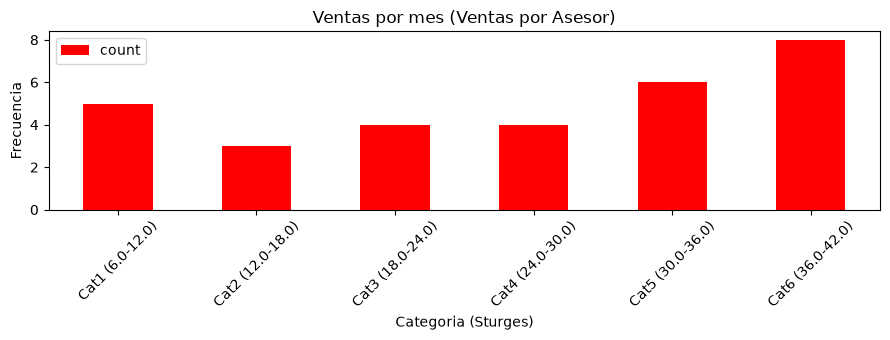

--- Conversaciones iniciadas por asesor (n=13, 5 clases) ---


,Categoria,count
0,Cat1 (5.0-9.4),5
1,Cat2 (9.4-13.8),2
2,Cat3 (13.8-18.2),3
3,Cat4 (18.2-22.6),2
4,Cat5 (22.6-27.0),1


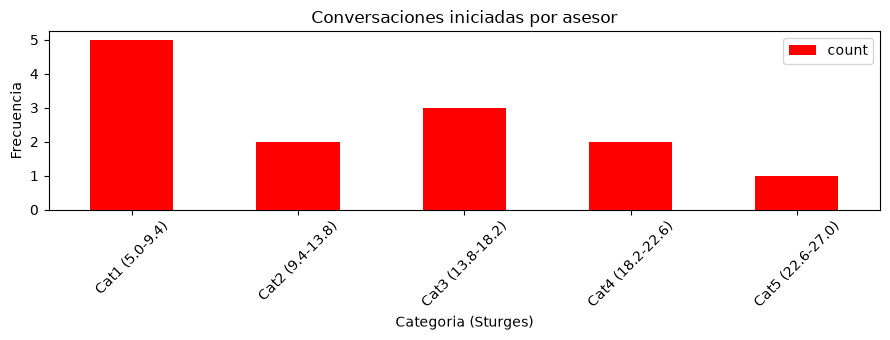

--- Afluencia real a piso por mes (TOPS MKT) (n=11, 4 clases) ---


,Categoria,count
0,Cat1 (43.0-52.5),1
1,Cat2 (52.5-62.0),2
2,Cat3 (62.0-71.5),4
3,Cat4 (71.5-81.0),4


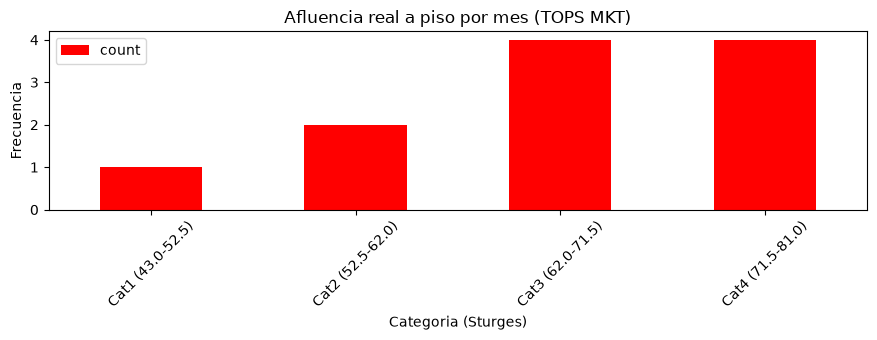

--- Objetivo de ventas por mes (TOPS VENTAS) (n=12, 5 clases) ---


,Categoria,count
0,Cat1 (35.0-38.6),3
1,Cat2 (38.6-42.2),3
2,Cat3 (42.2-45.8),1
3,Cat4 (45.8-49.4),3
4,Cat5 (49.4-53.0),2


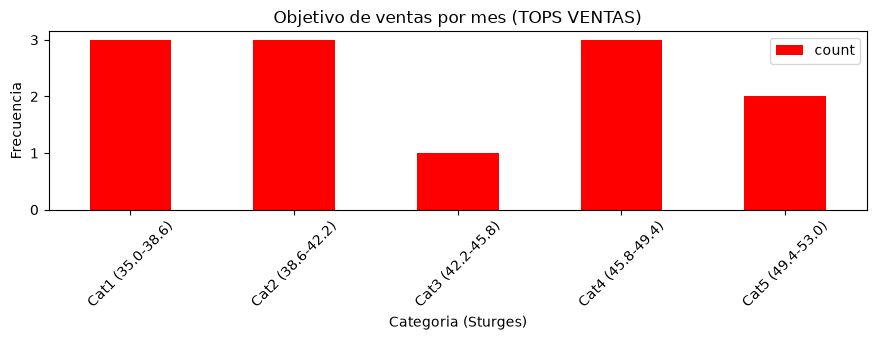

--- Leads totales 2024 por asesor (Analisis de Piso) (n=40, 6 clases) ---


,Categoria,count
0,Cat1 (1.0-35.2),27
1,Cat2 (35.2-69.3),8
2,Cat3 (69.3-103.5),1
3,Cat4 (103.5-137.7),3
4,Cat5 (137.7-171.8),0
5,Cat6 (171.8-206.0),1


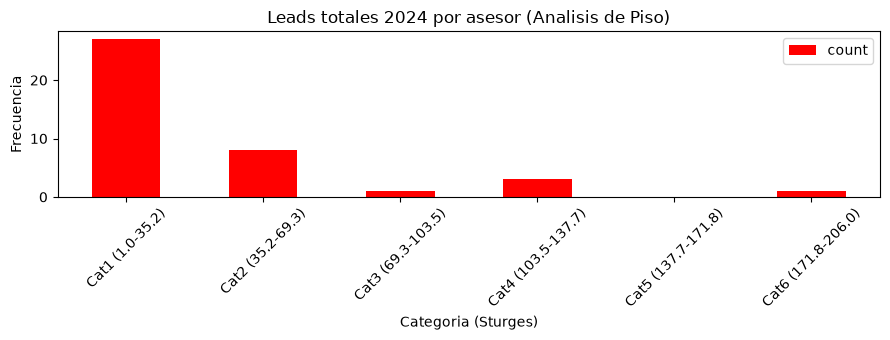

In [19]:
#Diccionario con las 9 variables numericas restantes
variables_numericas = {
    'Solicitudes de credito generadas (SDC)': SDC_Generadas,
    'Solicitudes de credito aprobadas (SDC)': SDC_Aprobadas,
    'Leads Facebook por mes (CPL Facebook)': Leads_Facebook,
    'Costo por lead Facebook (CPL Facebook)': Costo_por_Lead,
    'Ventas por mes (Ventas por Asesor)': Ventas_x_Mes,
    'Conversaciones iniciadas por asesor': Conversaciones,
    'Afluencia real a piso por mes (TOPS MKT)': Real_Pisos,
    'Objetivo de ventas por mes (TOPS VENTAS)': Objetivo_Ventas,
    'Leads totales 2024 por asesor (Analisis de Piso)': Leads_x_Asesor,
}

for nombre, datos in variables_numericas.items():
    categorizar_sturges(datos, nombre)